In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from loaders._load_vn30_reg import preprocess, VN30, TARGETS
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [3]:
_ = preprocess("ACB", verbose=True)

=== Preprocessing ACB ===
Feature shapes in train: (1215, 120), val: (0, 120), test: (328, 120)
Target shapes in train: (1215, 4), val: (0, 4), test: (328, 4)


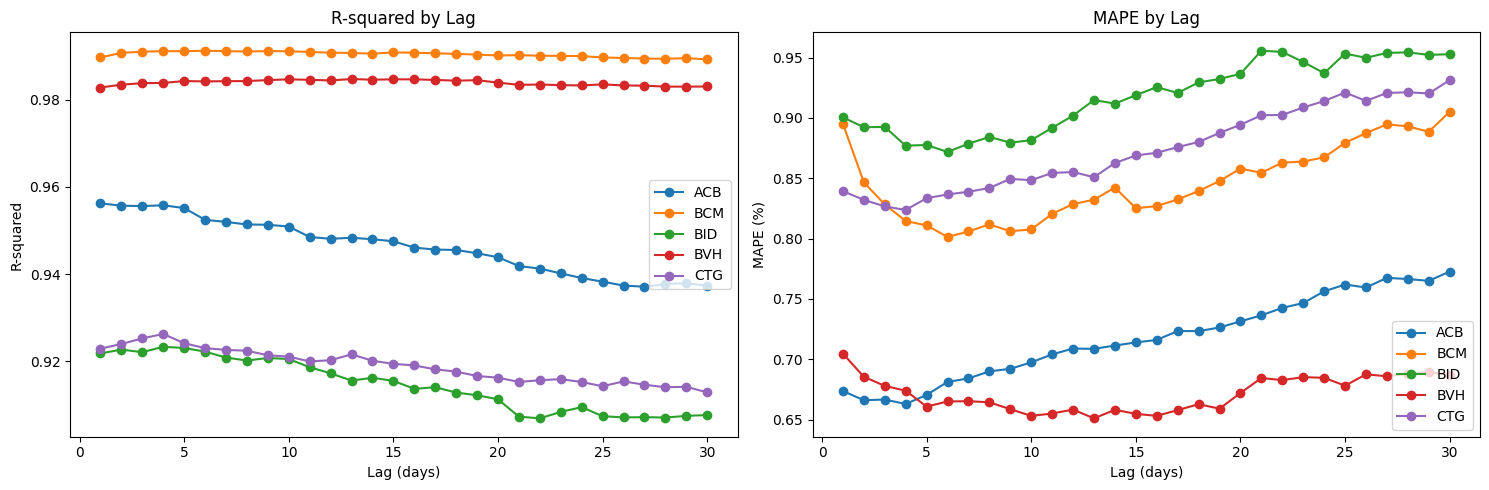

Best Lag for R-squared: 2
Best Lag for MAPE: 4


In [10]:
symbols = VN30[:5]

r2_by_lag = {symbol: [] for symbol in symbols}
mape_by_lag = {symbol: [] for symbol in symbols}

for lag in range(1, 31):
    for symbol in symbols:
        data = preprocess(symbol, lag=lag, val=0.2)
        X_train, Y_train = data['train']
        X_val, Y_val = data['val']
        X_test, Y_test = data['test']
        target_scaler = data['scaler']['target']

        model = LinearRegression()
        model.fit(X_train, Y_train)

        Y_pred = model.predict(X_val)
        Y_pred = target_scaler.inverse_transform(Y_pred)
        Y_val = target_scaler.inverse_transform(Y_val)

        r2 = r2_score(Y_val, Y_pred)
        mape = mean_absolute_percentage_error(Y_val, Y_pred) * 100

        r2_by_lag[symbol].append(r2)
        mape_by_lag[symbol].append(mape)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

for symbol in symbols:
    axes[0].plot(range(1, 31), r2_by_lag[symbol], marker='o', label=symbol)
    axes[1].plot(range(1, 31), mape_by_lag[symbol], marker='o', label=symbol)

axes[0].set_title(f"R-squared by Lag")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("R-squared")
axes[0].legend()

axes[1].set_title(f"MAPE by Lag")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("MAPE (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best Lag for R-squared: {np.argmax(np.array([np.max(r2_by_lag[symbol]) for symbol in symbols])) + 1}")
print(f"Best Lag for MAPE: {np.argmin(np.array([np.min(mape_by_lag[symbol]) for symbol in symbols])) + 1}")

In [11]:
track = {"r2": [], "mape": []}
for symbol in VN30:
    data = preprocess(symbol, lag=2)
    X_train, Y_train = data['train']
    X_val, Y_val = data['val']
    X_test, Y_test = data['test']
    target_scaler = data['scaler']['target']

    model = LinearRegression()
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)
    Y_pred = target_scaler.inverse_transform(Y_pred)
    Y_test = target_scaler.inverse_transform(Y_test)

    r2 = r2_score(Y_test, Y_pred)
    mape = mean_absolute_percentage_error(Y_test, Y_pred) * 100

    track["r2"].append(r2)
    track["mape"].append(mape)

    print(f"Symbol: {symbol}, R^2: {r2:.4f}, MAPE: {mape:.4f}")

print(f"Mean R^2: {np.mean(track['r2']):.4f}, Mean MAPE: {np.mean(track['mape']):.4f}")
print(f"Std R^2: {np.std(track['r2']):.4f}, Std MAPE: {np.std(track['mape']):.4f}")

Symbol: ACB, R^2: 0.9615, MAPE: 0.6514
Symbol: BCM, R^2: 0.9680, MAPE: 1.0712
Symbol: BID, R^2: 0.9385, MAPE: 0.8352
Symbol: BVH, R^2: 0.9850, MAPE: 0.8571
Symbol: CTG, R^2: 0.9766, MAPE: 0.8622
Symbol: FPT, R^2: 0.9934, MAPE: 0.8879
Symbol: GAS, R^2: 0.9679, MAPE: 0.6465
Symbol: GVR, R^2: 0.9781, MAPE: 1.3301
Symbol: HDB, R^2: 0.9835, MAPE: 0.8463
Symbol: HPG, R^2: 0.9352, MAPE: 0.8068
Symbol: LPB, R^2: 0.9970, MAPE: 0.9583
Symbol: MBB, R^2: 0.9718, MAPE: 0.8044
Symbol: MSN, R^2: 0.9689, MAPE: 0.9080
Symbol: MWG, R^2: 0.9883, MAPE: 0.9505
Symbol: PLX, R^2: 0.9862, MAPE: 0.8779
Symbol: SAB, R^2: 0.9520, MAPE: 0.7704
Symbol: SHB, R^2: 0.9724, MAPE: 0.8005
Symbol: SSB, R^2: 0.9667, MAPE: 0.7857
Symbol: SSI, R^2: 0.9538, MAPE: 0.9232
Symbol: STB, R^2: 0.9854, MAPE: 0.8774
Symbol: TCB, R^2: 0.9856, MAPE: 0.8689
Symbol: TPB, R^2: 0.9660, MAPE: 0.9032
Symbol: VCB, R^2: 0.9175, MAPE: 0.6169
Symbol: VHM, R^2: 0.9779, MAPE: 0.9077
Symbol: VIB, R^2: 0.9515, MAPE: 0.7627
Symbol: VIC, R^2: 0.9824,

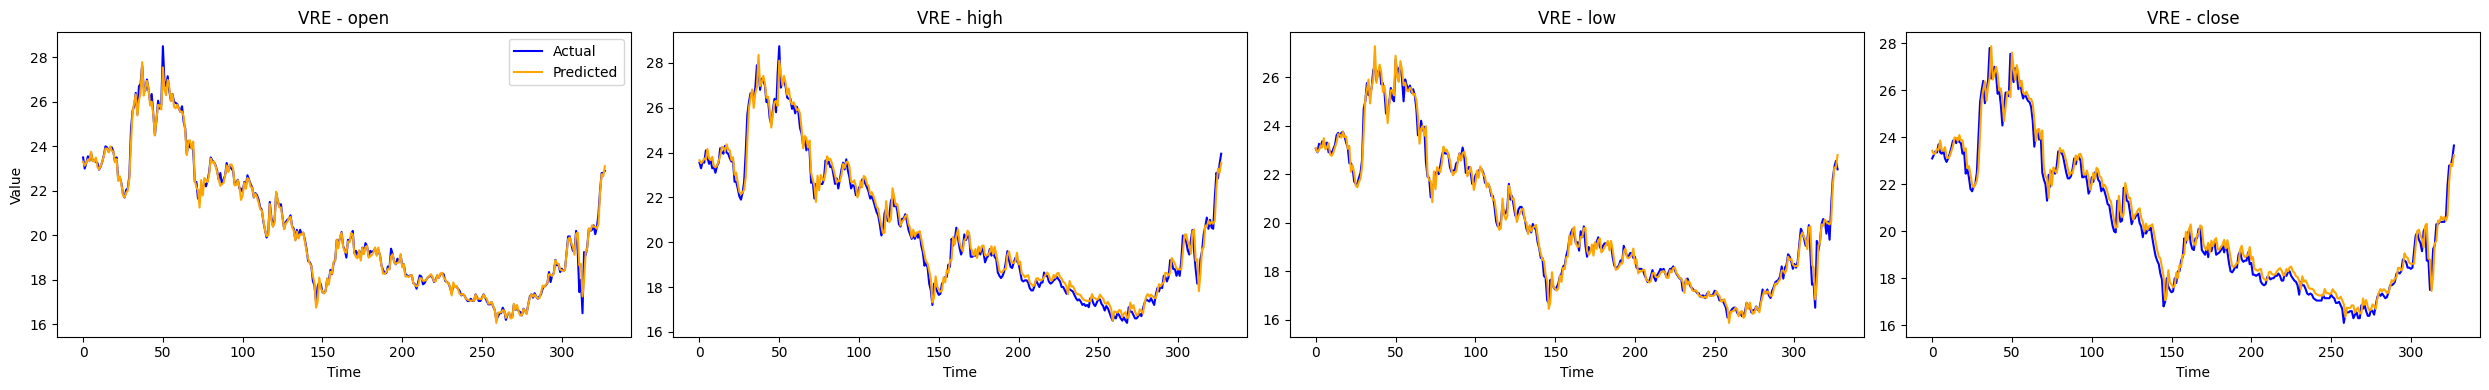

In [8]:
import matplotlib.pyplot as plt

# 4 subplots nằm ngang: 1 hàng x 4 cột
fig, axes = plt.subplots(1, 4, figsize=(25, 4), sharex=True)    

for i, name in enumerate(TARGETS):
    ax = axes[i]
    ax.plot(Y_test[:, i], label='Actual', color='blue')
    ax.plot(Y_pred[:, i], label='Predicted', color='orange')
    ax.set_title(f"{symbol} - {name}")
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel("Value")
        ax.legend()

plt.tight_layout()
plt.show()      